# Student Mental Health Analysis

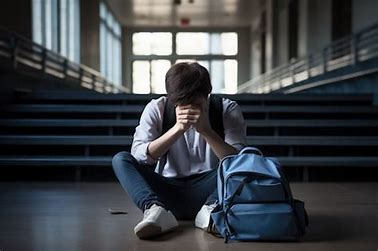

#### Feature Descriptions:

<div style="border: 1px solid #455A64; background-color: #ECEFF1; padding: 15px; border-radius: 6px; font-family: Arial, sans-serif;">
  <strong>Feature Explanations</strong><br><br>
  <table style="width: 100%; border-collapse: collapse; font-size: 14px;">
    <thead>
      <tr>
        <th style="border-bottom: 1px solid #999; text-align: left; padding: 8px;">Feature</th>
        <th style="border-bottom: 1px solid #999; text-align: left; padding: 8px;">Explanation</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px;">Timestamp</td>
        <td style="padding: 8px;">Date and time of the response</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Choose your gender</td>
        <td style="padding: 8px;">Respondent’s gender</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Age</td>
        <td style="padding: 8px;">Respondent’s age</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Respondent’s field of study</td>
        <td style="padding: 8px;">Field of study</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Your current year of Study</td>
        <td style="padding: 8px;">Academic year</td>
      </tr>
      <tr>
        <td style="padding: 8px;">What is your CGPA?</td>
        <td style="padding: 8px;">Grade average range</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Marital status</td>
        <td style="padding: 8px;">Single or married status</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Do you have Depression?</td>
        <td style="padding: 8px;">Has depression (Yes/No)</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Do you have Anxiety?</td>
        <td style="padding: 8px;">Has anxiety (Yes/No)</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Do you have Panic attack?</td>
        <td style="padding: 8px;">Has panic attacks (Yes/No)</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Did you seek any specialist for a treatment?</td>
        <td style="padding: 8px;">Sought professional help (Yes/No)</td>
      </tr>
    </tbody>
  </table>
</div>


# Importing Essential Libraries and Metrics

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings('ignore')

## Loading the Data

In [2]:
df = pd.read_csv("/kaggle/input/student-mental-health/Student Mental health.csv")
df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


# 1.Summary of The Data

In [3]:
df.shape

(101, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

<div style="border: 1px solid #546E7A; background-color: #CFD8DC; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  The name of each column represents one question in this survey.
</div>


In [5]:
df.isnull().sum() 

Timestamp                                       0
Choose your gender                              0
Age                                             1
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64

<div style="border: 1px solid #F57C00; background-color: #FFF3E0; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  One value is missing in the <strong>'Age'</strong> column.
</div>


In [6]:
df.dtypes

Timestamp                                        object
Choose your gender                               object
Age                                             float64
What is your course?                             object
Your current year of Study                       object
What is your CGPA?                               object
Marital status                                   object
Do you have Depression?                          object
Do you have Anxiety?                             object
Do you have Panic attack?                        object
Did you seek any specialist for a treatment?     object
dtype: object

<div style="border: 1px solid #616161; background-color: #F5F5F5; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  Only two data types are shown, <strong>'object'</strong> and <strong>'float'</strong>.
</div>


In [7]:
df.describe()

,Age
count,100.00000
mean,20.53000
std,2.49628
min,18.00000
25%,18.00000
50%,19.00000
75%,23.00000
max,24.00000


In [8]:
df.describe(include='O')

,Timestamp,Choose your gender,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
count,101,101,101,101,101,101,101,101,101,101
unique,92,2,49,7,6,2,2,2,2,2
top,8/7/2020 12:39,Female,BCS,year 1,3.50 - 4.00,No,No,No,No,No
freq,3,75,18,41,47,85,66,67,68,95


<div style="border: 1px solid #455A64; background-color: #ECEFF1; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  Since some columns in the table above might have many unique values, they will be examined.
</div>


In [9]:
df['What is your course?'].value_counts()

What is your course?
BCS                        18
Engineering                17
BIT                        10
KOE                         4
Biomedical science          4
psychology                  2
BENL                        2
Engine                      2
Laws                        2
Irkhs                       1
Psychology                  1
Accounting                  1
KENMS                       1
Mathemathics                1
Pendidikan islam            1
Human Resources             1
Islamic education           1
Business Administration     1
Banking Studies             1
Marine science              1
ENM                         1
TAASL                       1
Usuluddin                   1
ALA                         1
Law                         1
koe                         1
Kirkhs                      1
Benl                        1
IT                          1
CTS                         1
engin                       1
Econs                       1
KIRKHS             

<div style="border: 1px solid #6D4C41; background-color: #EFEBE9; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  Some students wrote the names of their faculty or department in full, while others used abbreviations or alternative spellings. This resulted in the creation of additional categories.
</div>


In [10]:
# list the frequencies in 'Your current year of Study' column
df['Your current year of Study'].value_counts()

Your current year of Study
year 1    41
Year 3    19
Year 2    16
year 2    10
year 4     8
year 3     5
Year 1     2
Name: count, dtype: int64

<div style="border: 1px solid #283593; background-color: #E8EAF6; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  The difference in capitalization between "year" and "Year" has resulted in seven distinct categories.
</div>


In [11]:
df['What is your CGPA?'].value_counts()

What is your CGPA?
3.50 - 4.00     47
3.00 - 3.49     43
2.50 - 2.99      4
0 - 1.99         4
2.00 - 2.49      2
3.50 - 4.00      1
Name: count, dtype: int64

<div style="border: 1px solid #C62828; background-color: #FFEBEE; padding: 10px; border-radius: 6px; font-family: Arial, sans-serif;">
  The same category appears twice, indicating a discrepancy in spelling.
</div>


# 2.Data Exploration Plan

<div style="border: 1px solid #455A64; background-color: #ECEFF1; padding: 15px; border-radius: 6px; font-family: Arial, sans-serif;">
  <strong>This analysis investigates whether mental health issues such as depression, anxiety, and panic attacks are associated with academic performance (CGPA) among university students.</strong>
  <br><br>
  <strong>Primary Objective</strong><br>
  The main focus is to examine the potential impact of mental health on CGPA.<br>
  The key question addressed is:<br><br>
  Whether students experiencing mental health problems tend to have lower CGPA scores compared to those without such issues.<br><br>
  To support this objective, relationships between CGPA and several mental health indicators (depression, anxiety, panic attacks), along with relevant demographic (gender, age, marital status) and academic (course, year of study) factors, are explored.<br><br>
  <strong>Bidirectional Analysis</strong><br>
  A two-way investigation of the relationship is possible:<br><br>
  Mental Health → Academic Performance<br>
  The tendency of students with depression, anxiety, or panic attacks to perform worse academically (lower CGPA) is examined.<br>
  Academic Performance → Mental Health<br>
  The likelihood of students with lower CGPA scores experiencing stress, anxiety, or depression due to academic pressure is assessed.<br><br>
  <strong>Methods and Tools</strong><br>
  Analysis of these relationships involves:<br><br>
  Visualizations: bar charts, box plots, and count plots<br>
  Summary statistics and cross-tabulations<br>
  Hypothesis testing to determine significant differences between groups
</div>


# 3.Data Cleaning

<div style="border: 1px solid #37474F; background-color: #CFD8DC; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
  At the end of Section 1, we observed that some columns contain incorrect or inconsistent category values, and one column has missing data. Before proceeding to Exploratory Data Analysis (EDA), it is important to address these issues.<br><br>
  In this step, we will correct mislabeled categories and appropriately handle missing values. This cleaning process will enable us to better understand the data and generate more accurate and meaningful visualizations later.
</div>


In [12]:
df.rename(columns={
    'Timestamp': 'timestamp',
    'Choose your gender': 'gender',
    'Age': 'age',
    'What is your course?': 'course',
    'Your current year of Study': 'study_year',
    'What is your CGPA?': 'cgpa',
    'Marital status': 'marital_status',
    'Do you have Depression?': 'depression',
    'Do you have Anxiety?': 'anxiety',
    'Do you have Panic attack?': 'panic_attack',
    'Did you seek any specialist for a treatment?': 'seek_treatment'
}, inplace=True)


df.course.unique()

array(['Engineering', 'Islamic education', 'BIT', 'Laws', 'Mathemathics',
       'Pendidikan islam', 'BCS', 'Human Resources', 'Irkhs',
       'Psychology', 'KENMS', 'Accounting ', 'ENM', 'Marine science',
       'KOE', 'Banking Studies', 'Business Administration', 'Law',
       'KIRKHS', 'Usuluddin ', 'TAASL', 'Engine', 'ALA',
       'Biomedical science', 'koe', 'Kirkhs', 'BENL', 'Benl', 'IT', 'CTS',
       'engin', 'Econs', 'MHSC', 'Malcom', 'Kop', 'Human Sciences ',
       'Biotechnology', 'Communication ', 'Diploma Nursing',
       'Pendidikan Islam ', 'Radiography', 'psychology', 'Fiqh fatwa ',
       'DIPLOMA TESL', 'Koe', 'Fiqh', 'Islamic Education', 'Nursing ',
       'Pendidikan Islam'], dtype=object)

<div style="border: 1px solid #546E7A; background-color: #CFD8DC; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
  In this survey, students gave varied and different answers to the question "What is your course?". Even students enrolled in the same course provided different responses. This inconsistency in answers can create confusion when analyzing and visualizing the data.<br><br>
  Therefore, listing each department under its respective faculty will make the data more coherent and help in drawing meaningful conclusions. This listing was made based on an informative article by a user named Roman Nikiforov on Kaggle.com.<br><br>
  Big thanks to Roman Nikiforov for the helpful post!
</div>


## course_mapping

In [13]:
course_mapping = {
    'BCS' : 'IT',
    'Engineering': 'Engineering',
    'BIT': 'IT',
    'IT': 'IT',
    'Biomedical science': 'Medicine',
    'KOE' : 'Engineering',
    'BENL' : 'Linguistics',
    'Laws': 'Law',
    'psychology': 'Religion, sociology and ethnography and psychology (RSEP)',
    'Engine': 'Engineering',
    'Islamic Education': 'Religion, sociology and ethnography and psychology (RSEP)',
    'Biotechnology': 'Medicine',
    'engin': 'Engineering',
    'Econs' : 'Economics and management',
    'MHSC' : 'Medicine',
    'Malcom' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Kop' : 'Medicine',
    'Human Sciences ': 'Religion, sociology and ethnography and psychology (RSEP)',
    'Communication ': 'Religion, sociology and ethnography and psychology (RSEP)',
    'Nursing ': 'Medicine',
    'Diploma Nursing': 'Medicine',
    'Pendidikan Islam ' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Pendidikan Islam' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Radiography': 'Medicine',
    'Fiqh fatwa ': 'Law',
    'DIPLOMA TESL' : 'Linguistics',
    'Koe': 'Engineering',
    'Fiqh': 'Law',
    'CTS' : 'IT',
    'koe': 'Engineering',
    'Benl' : 'Linguistics',
    'Kirkhs' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Mathemathics': 'Economics and management',
    'Human Resources': 'Economics and management',
    'Irkhs' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Psychology': 'Religion, sociology and ethnography and psychology (RSEP)',
    'KENMS' : 'Economics and management',
    'Accounting ': 'Economics and management',
    'ENM' : 'Environment',
    'Marine science': 'Environment',
    'Banking Studies': 'Economics and management',
    'Business Administration': 'Economics and management',
    'Law': 'Law',
    'KIRKHS' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'Usuluddin ' : 'Religion, sociology and ethnography and psychology (RSEP)',
    'TAASL' : 'Linguistics',
    'ALA' : 'Art',
    'Islamic education': 'Religion, sociology and ethnography and psychology (RSEP)',
    'Pendidikan islam' : 'Religion, sociology and ethnography and psychology (RSEP)',
}

df['course_category'] = df['course'].map(course_mapping)

unmapped_courses = df[df['course_category'].isna()]['course'].unique()

df['course_category'].value_counts()

course_category
IT                                                           30
Engineering                                                  26
Religion, sociology and ethnography and psychology (RSEP)    15
Medicine                                                     10
Economics and management                                      7
Law                                                           5
Linguistics                                                   5
Environment                                                   2
Art                                                           1
Name: count, dtype: int64

In [14]:
print(unmapped_courses)
print(df.course_category.value_counts().sum())

[]
101


<div style="border: 1px solid #4CAF50; background-color: #E8F5E9; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
  Now it is fine.
</div>


In [15]:
df.study_year.value_counts()

study_year
year 1    41
Year 3    19
Year 2    16
year 2    10
year 4     8
year 3     5
Year 1     2
Name: count, dtype: int64

In [16]:
df['study_year'] = df['study_year'].str.lower().str.strip()

df.study_year.value_counts()

study_year
year 1    43
year 2    26
year 3    24
year 4     8
Name: count, dtype: int64

<div style="border: 1px solid #4CAF50; background-color: #E8F5E9; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
    Fixed
</div>


In [17]:
df['cgpa'].value_counts()

cgpa
3.50 - 4.00     47
3.00 - 3.49     43
2.50 - 2.99      4
0 - 1.99         4
2.00 - 2.49      2
3.50 - 4.00      1
Name: count, dtype: int64

In [18]:
df.cgpa = df.cgpa.str.strip()

df['cgpa'].value_counts()

cgpa
3.50 - 4.00    48
3.00 - 3.49    43
2.50 - 2.99     4
0 - 1.99        4
2.00 - 2.49     2
Name: count, dtype: int64

In [19]:
df.isnull().sum()

timestamp          0
gender             0
age                1
course             0
study_year         0
cgpa               0
marital_status     0
depression         0
anxiety            0
panic_attack       0
seek_treatment     0
course_category    0
dtype: int64

<div style="border: 1px solid #546E7A; background-color: #CFD8DC; padding: 15px; border-radius: 6px; font-family: Arial, sans-serif;">
  At this point, it's important to understand the dataset well. Missing data should be handled carefully. In some cases, it can be filled in; in others, it might need to be removed. But removing missing data can sometimes lead to a loss of useful information and affect the results.<br><br>
  The dataset reflects responses from a survey conducted among university students. Most respondents are likely between the ages of 18 and 22, which can be confirmed by examining the average age recorded in the "age" column.
</div>


In [20]:
df.age.mean()

20.53

<div style="border: 1px solid #00796B; background-color: #E0F2F1; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
  Filling the missing values in the <strong>"age"</strong> column with the average value (e.g., 20) appears to be the most appropriate option.
</div>


In [21]:
df['age'] = df['age'].fillna(20) 


# convert the data type of the "age" column to int
df.age = df.age.astype(int)

<div style="border: 1px solid #283593; background-color: #E8EAF6; padding: 12px; border-radius: 6px; font-family: Arial, sans-serif;">
  As a final step of this section, we will work on the <strong>'timestamp'</strong> column.
</div>


In [22]:
df.timestamp

0           8/7/2020 12:02
1           8/7/2020 12:04
2           8/7/2020 12:05
3           8/7/2020 12:06
4           8/7/2020 12:13
              ...         
96     13/07/2020 19:56:49
97     13/07/2020 21:21:42
98     13/07/2020 21:22:56
99     13/07/2020 21:23:57
100    18/07/2020 20:16:21
Name: timestamp, Length: 101, dtype: object

<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Student Mental Health Analysis</title>
    <style>
        body {
            font-family: Arial, sans-serif;
        }
        .container {
            max-width: 800px;
            margin: 0 auto;
            padding: 20px;
        }
        .section {
            border: 1px solid #ccc;
            padding: 10px;
            margin-bottom: 20px;
        }
        table {
            width: 100%;
            border-collapse: collapse;
        }
        th, td {
            border: 1px solid #ddd;
            padding: 8px;
            text-align: left;
        }
        pre {
            background-color: #f4f4f4;
            padding: 10px;
            border: 1px solid #ddd;
        }
    </style>
</head>
<body>
    <div class="container">
        <h1>Student Mental Health Analysis</h1>
        <div class="section">
            <h2>Standardizing Date Formats</h2>
            <p>To improve the visualization of date values in the <code>timestamp</code> column, the <code>to_datetime</code> function from the pandas library should be used. Since the date formats vary between rows, the formats need to be standardized first.</p>
            <h3>Here are a few examples of the date values:</h3>
            <table>
                <tr>
                    <th>Row</th>
                    <th>Date Value</th>
                </tr>
                <tr>
                    <td>0</td>
                    <td>8/7/2020 12:02</td>
                </tr>
                <tr>
                    <td>...</td>
                    <td>...</td>
                </tr>
                <tr>
                    <td>100</td>
                    <td>18/07/2020 20:16:21</td>
                </tr>
            </table>
            <p>Once the formats are made consistent, they can be correctly parsed using the <code>pd.to_datetime()</code> function.</p>
        </div>
        <div class="section">
            <pre>
[17]: df['timestamp'] = df['timestamp'].apply(lambda x: x if len(x.split(':')) == 3 else x + ':00')
            </pre>
        </div>
    </div>
</body>
</html>

In [23]:
df['timestamp'] = df['timestamp'].apply(lambda x: x if len(x.split(':')) == 3 else x + ':00')


df.timestamp

0        8/7/2020 12:02:00
1        8/7/2020 12:04:00
2        8/7/2020 12:05:00
3        8/7/2020 12:06:00
4        8/7/2020 12:13:00
              ...         
96     13/07/2020 19:56:49
97     13/07/2020 21:21:42
98     13/07/2020 21:22:56
99     13/07/2020 21:23:57
100    18/07/2020 20:16:21
Name: timestamp, Length: 101, dtype: object

<div style="border: 1px solid #4CAF50; background-color: #e8f5e9; padding: 10px; border-radius: 5px;">
   <strong>Fixed — ready to apply <code>to_datetime</code></strong>
</div>


In [24]:
df_date = df[['timestamp']].copy()
df_date['timestamp'] = pd.to_datetime(df_date['timestamp'], format='%d/%m/%Y %H:%M:%S')

In [25]:
df_date['day'] = df_date['timestamp'].dt.day
df_date['month'] = df_date['timestamp'].dt.month_name()
df_date['year'] = df_date['timestamp'].dt.year



# 4.Exploratory Data Analysis

In [26]:
df.sample(random_state=42)

,timestamp,gender,age,course,study_year,cgpa,marital_status,depression,anxiety,panic_attack,seek_treatment,course_category
84,13/07/2020 10:14:46,Male,23,Radiography,year 1,3.00 - 3.49,No,No,No,No,No,Medicine


Categorical Variables: time-info(df_date), gender, study_year, cgpa, marital_status, depression, anxiety, panic_attack, seek_treatment, course_category

Numeric Variables: age

## 4.1 Univariate Analysis for Categorical Variables

time-info

<div style="border: 1px solid #1976D2; background-color: #E3F2FD; padding: 10px; border-radius: 5px;">
   <strong>Let's start our EDA by exploring the time-related information stored in <code>df_date</code>.</strong>
</div>


In [27]:
# convert day and year to string to use as categorical axes in plots
df_date[['day', 'year']] = df_date[['day', 'year']].astype(str)

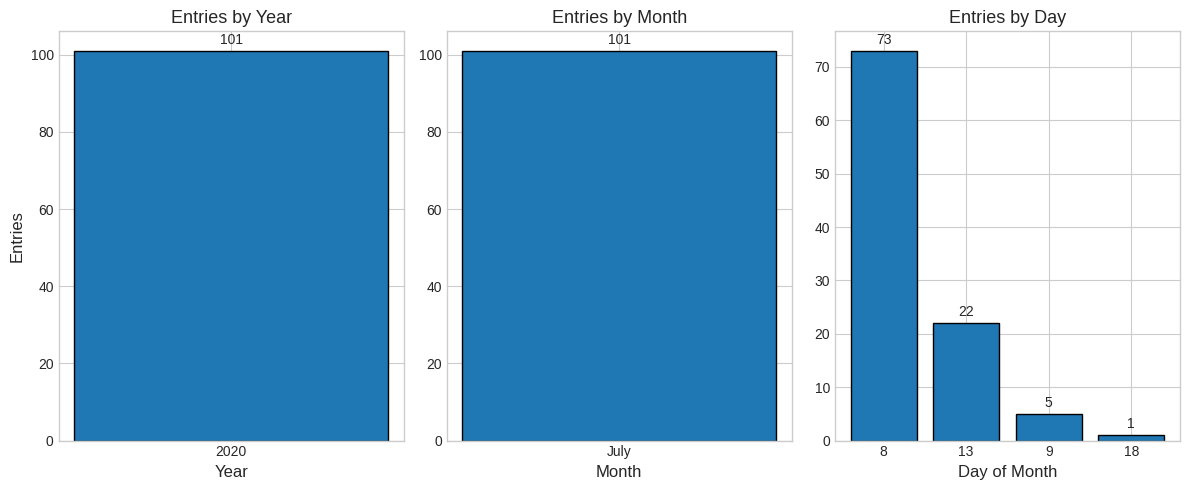

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))

titles = ['Entries by Year', 'Entries by Month', 'Entries by Day']
x_labels = ['Year', 'Month', 'Day of Month']
columns = ['year', 'month', 'day']

for i, col in enumerate(columns):
    counts = df_date[col].value_counts()
    
    axes[i].bar(counts.index, counts.values, edgecolor='black')

    axes[i].set_title(titles[i], fontsize=13)
    axes[i].set_xlabel(x_labels[i], fontsize=12)
    if col == 'year':
        axes[i].set_ylabel('Entries', fontsize=12)

    axes[i].bar_label(axes[i].containers[0], fontsize=10, padding=3)

    axes[i].tick_params(axis='x', rotation=0, labelsize=10)
    axes[i].tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

<div style="border: 1px solid #616161; background-color: #f5f5f5; padding: 12px; border-radius: 5px;">
  🔍 <strong>Key Findings:</strong><br>
  The survey was done four times between <strong>July 8th and July 18th, 2020</strong>, and the results were recorded.<br>
  Since this doesn’t add much to our analysis, there is no need to look closely at the other date information.<br>
  👉 <strong>No further analysis of other date details is needed.</strong>
</div>


### 4.1.2 Distribution of Binary Categorical Variables

<div style="border: 1px solid #0288D1; background-color: #E1F5FE; padding: 10px; border-radius: 5px;">
   <strong>Selected Features for Analysis:</strong><br>
  <code>'gender'</code>, <code>'marital_status'</code>, <code>'depression'</code>, <code>'anxiety'</code>, <code>'panic_attack'</code>, <code>'seek_treatment'</code>
</div>


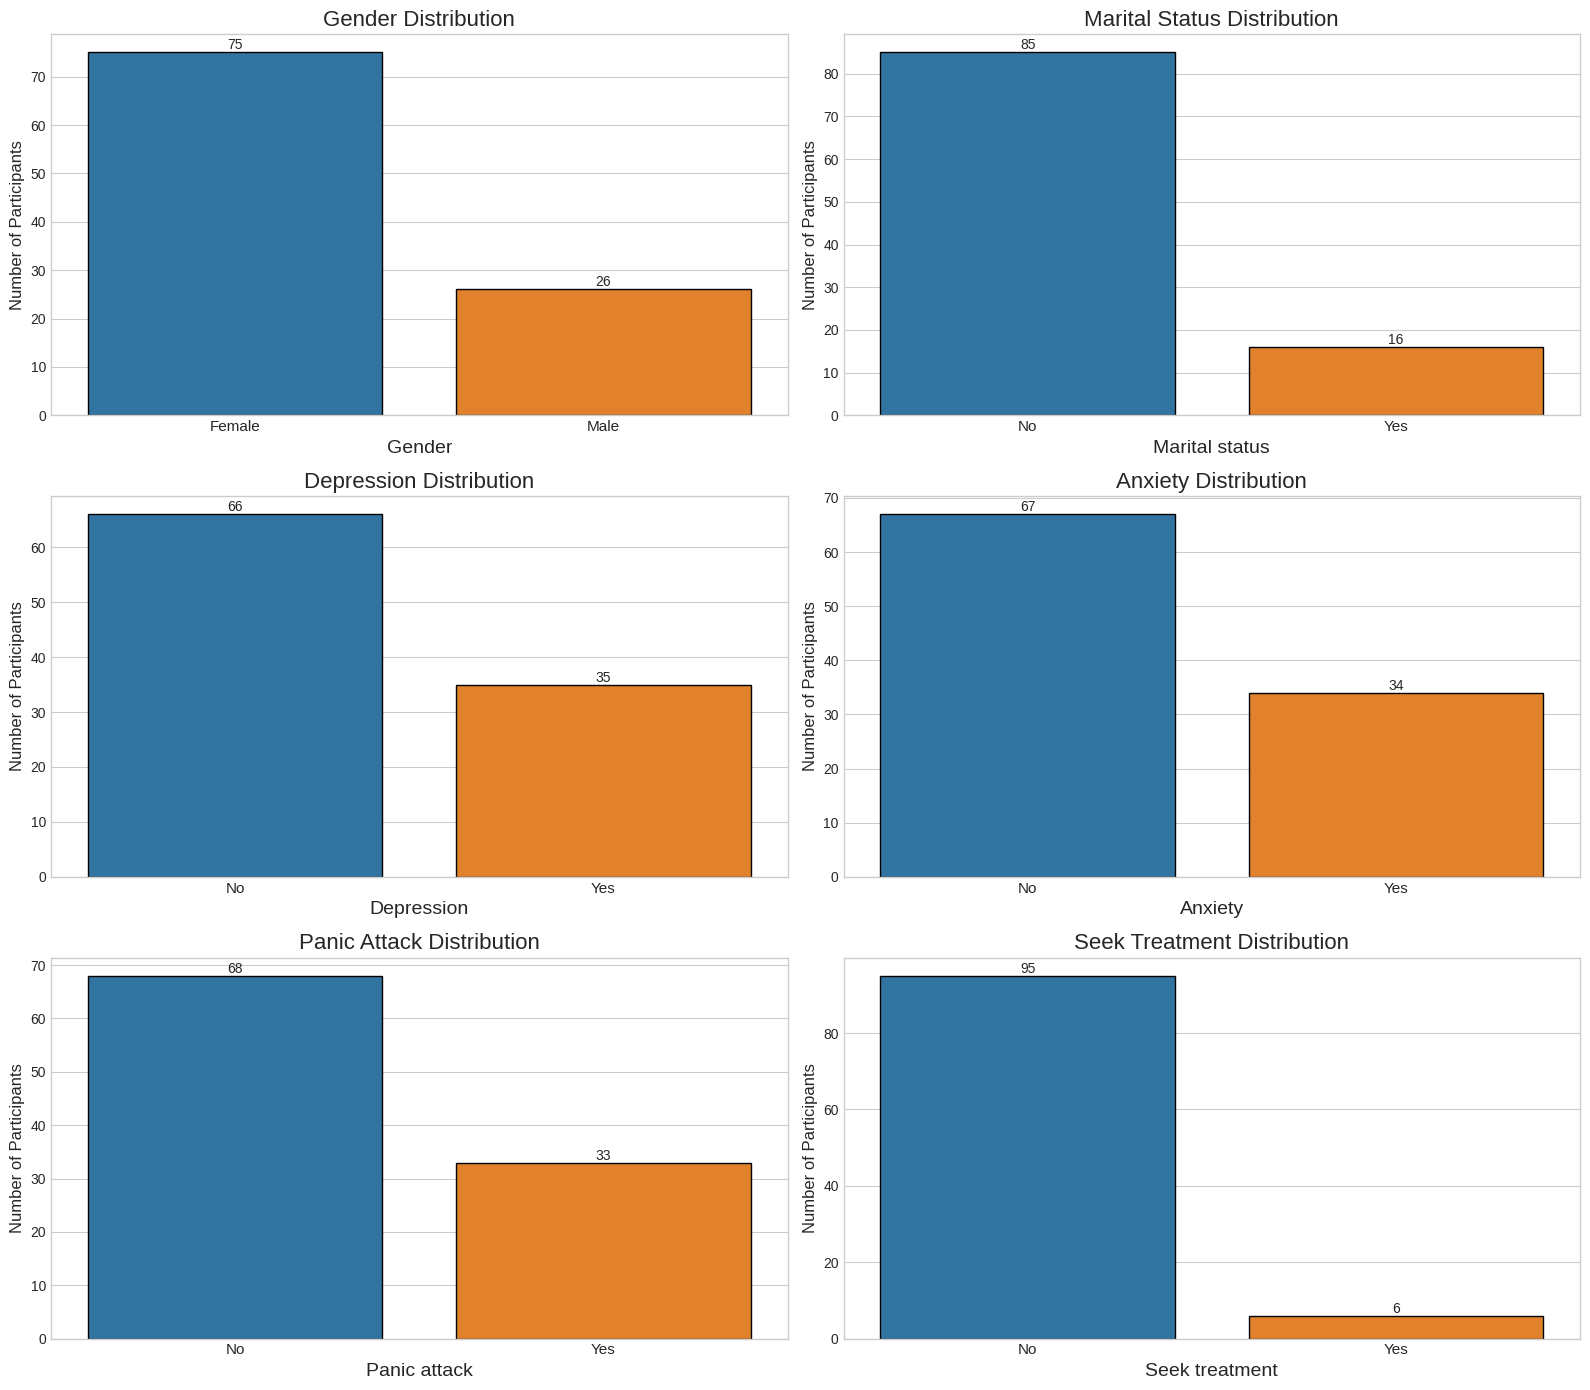

In [29]:
cols = ['gender', 'marital_status', 'depression', 'anxiety', 'panic_attack', 'seek_treatment']
titles = ['Gender Distribution', 'Marital Status Distribution', 'Depression Distribution',
          'Anxiety Distribution', 'Panic Attack Distribution', 'Seek Treatment Distribution']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14), dpi=100)
axes = axes.flatten()

for i, col in enumerate(cols):
    sorted_order = sorted(df[col].dropna().unique())
    
    graph = sns.countplot(data=df, x=col, edgecolor='black', ax=axes[i], order=sorted_order)
    
    axes[i].set_title(titles[i], fontsize=16)
    axes[i].set_xlabel(col.replace('_', ' ').capitalize(), fontsize=14)
    axes[i].set_ylabel('Number of Participants', fontsize=12)
    axes[i].tick_params(axis='x', labelrotation=0, labelsize=11)

    for cont in graph.containers:
        graph.bar_label(cont, fontsize=10)

plt.tight_layout()
plt.show()

<div style="border: 1px solid #4CAF50; background-color: #F1F8E9; padding: 15px; border-radius: 8px; font-size: 15px;">
   <strong>Key Findings:</strong><br><br>
  This figure shows six columns with yes/no answers. To avoid repeating code, using subplots for the visuals is more efficient.<br>
  Since the charts are clear and the numbers easy to read, this method helps to understand the data better.<br><br>
  • <strong>Gender:</strong> About three-quarters of participants are women, totaling <strong>75</strong> individuals.<br>
  • <strong>Marital Status:</strong> Only <strong>16</strong> people are married, which is expected since the survey involved university students.<br>
  • <strong>Depression:</strong> <strong>35</strong> individuals reported experiencing depression.<br>
  • <strong>Anxiety:</strong> <strong>34</strong> participants indicated feeling anxious.<br>
  • <strong>Panic Attacks:</strong> <strong>33</strong> students have experienced panic attacks.<br>
  • <strong>Seeking Treatment:</strong> Only <strong>6</strong> people sought treatment for these issues.
</div>


### 4.1.3 Distribution of "study_year"

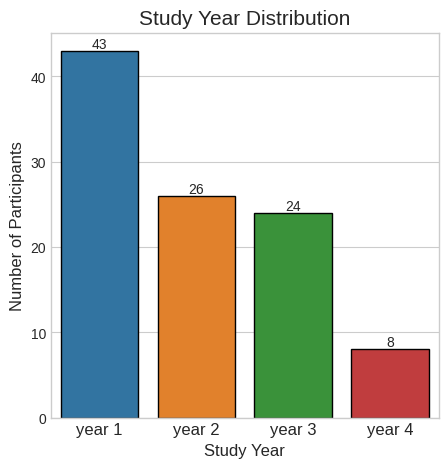

In [30]:
plt.figure(figsize=(5, 5), dpi=100)
graph = sns.countplot(data=df, x='study_year', edgecolor='black')
plt.xlabel('Study Year', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.title('Study Year Distribution', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
for cont in graph.containers:
        graph.bar_label(cont)
plt.show()

<div style="border: 1px solid #3F51B5; background-color: #E8EAF6; padding: 10px; border-radius: 5px;">
      <strong>Key Findings:</strong><br>
  The majority of the participants are first-year students.
</div>


### 4.1.4 Distribution of "cgpa"

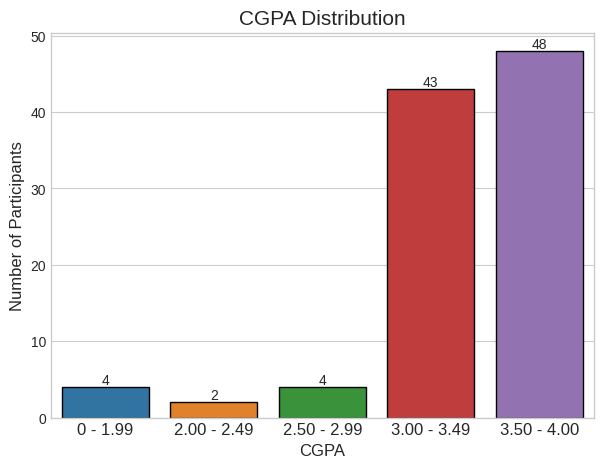

In [31]:
ordered_categories = ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99', '3.00 - 3.49', '3.50 - 4.00']
cgpa_sorted = pd.Categorical(df['cgpa'], categories=ordered_categories, ordered=True)

plt.figure(figsize=(7, 5), dpi=100)
graph = sns.countplot(data=df, x=cgpa_sorted, edgecolor='black')
plt.xlabel('CGPA', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.title('CGPA Distribution', fontsize=15)
plt.xticks(rotation=0, fontsize=12)
for cont in graph.containers:
        graph.bar_label(cont)
plt.show()

<div style="border: 1px solid #009688; background-color: #E0F2F1; padding: 10px; border-radius: 5px;">
   <strong>Key Findings:</strong><br>
  The majority of the participants have a CGPA between <strong>3.50 and 4.00</strong>.
</div>


### 4.1.5 Distribution of "course_category"

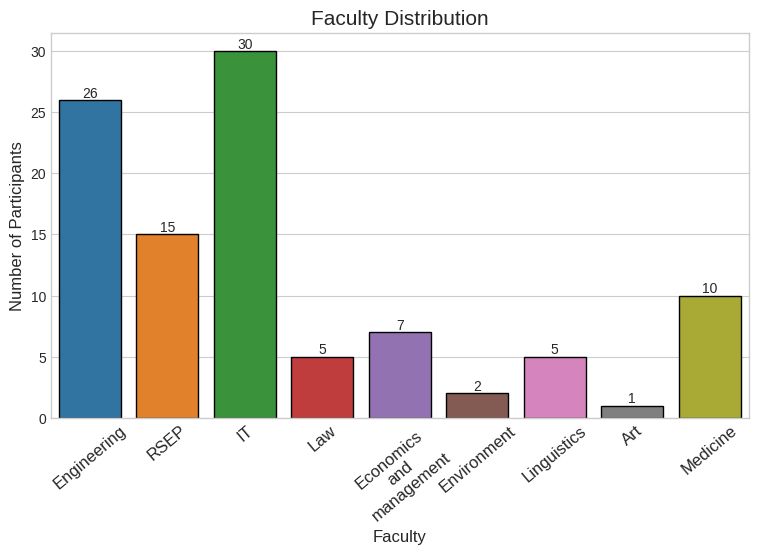

In [32]:
df_course = df['course_category'].replace({"Religion, sociology and ethnography and psychology (RSEP)": "RSEP",
                                          "Economics and management" : "Economics\nand\nmanagement"})

plt.figure(figsize=(9, 5), dpi=100)
graph = sns.countplot(data=df_course, x=df_course, edgecolor='black')
plt.xlabel('Faculty', fontsize=12)
plt.ylabel('Number of Participants', fontsize=12)
plt.title('Faculty Distribution', fontsize=15)
plt.xticks(rotation=40, fontsize=12)
for cont in graph.containers:
        graph.bar_label(cont)
plt.show()

<div style="border: 1px solid #673AB7; background-color: #EDE7F6; padding: 10px; border-radius: 6px;">
  🏫 <strong>Key Findings:</strong><br>
  The majority of the participants are studying in a department under the <strong>Faculty of Information Technology</strong>.
</div>


## 4.2 Univariate Analysis for Numerical Variables

### 4.2.1 Distribution of "age"

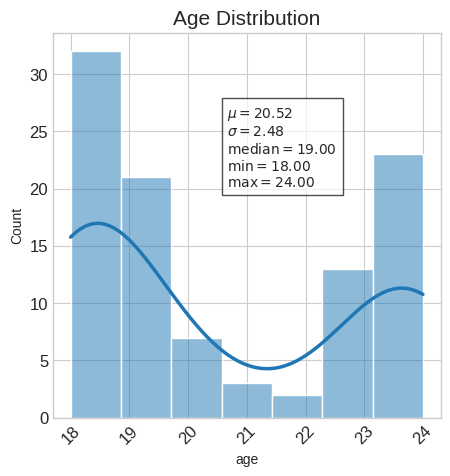

In [33]:
plt.figure(figsize=(5, 5), dpi=100)
graph = sns.histplot(data=df, x='age', bins=7, kde=True, edgecolor='white', alpha=0.5, line_kws={'lw': 2.5})
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.title('Age Distribution', fontsize=15)

textstr = '\n'.join((
    r'$\mu=%.2f$' %df['age'].mean(),
    r'$\sigma=%.2f$' %df['age'].std(),
    r'$\mathrm{median}=%.2f$' %np.median(df['age']),
    r'$\mathrm{min}=%.2f$' %df['age'].min(),
    r'$\mathrm{max}=%.2f$' %df['age'].max()
))

plt.text(0.45, 0.6, textstr, transform=graph.transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

plt.show()

<div style="border: 1px solid #FF9800; background-color: #FFF3E0; padding: 10px; border-radius: 6px;">
  🎂 <strong>Key Findings:</strong><br>
  The majority of the participants are <strong>18 years old</strong>.
</div>


## 4.3 Bivariate Analysis for Categorical Variables

4.3.1 "cgpa vs depression | anxiety | panic_attack | seek_treatment"

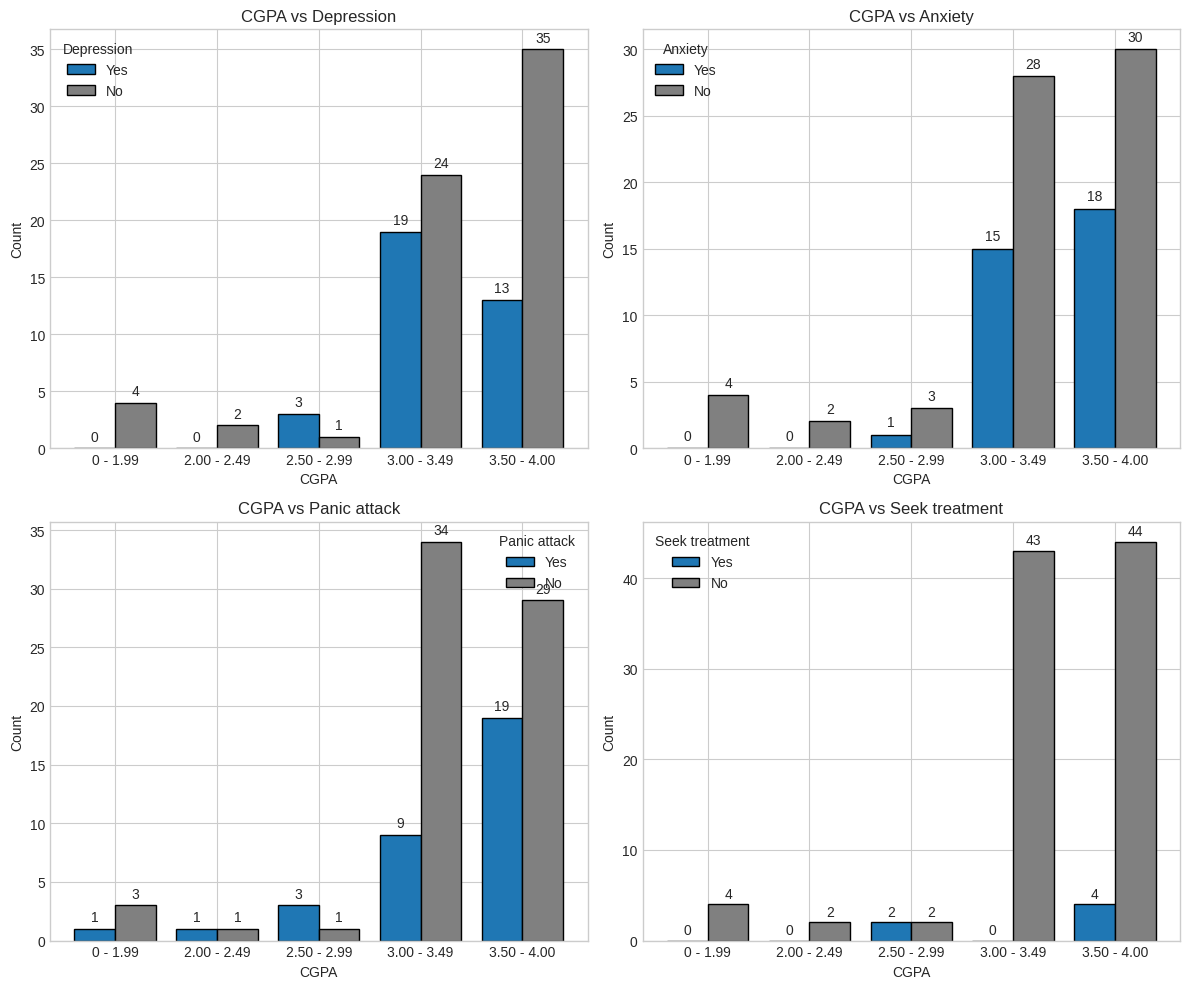

In [34]:
columns = ['depression', 'anxiety', 'panic_attack', 'seek_treatment']
crosstabs = {col: pd.crosstab(df['cgpa'], df[col]) for col in columns}

labels = crosstabs[columns[0]].index.tolist()
x = np.arange(len(labels))
width = 0.40 

fig, axes = plt.subplots(2, 2, figsize=(12, 10)) 

axes = axes.flatten()

for i, col in enumerate(columns):
    crosstab = crosstabs[col]
    yes_counts = crosstab['Yes'].tolist()
    no_counts = crosstab['No'].tolist()
    
    bars_yes = axes[i].bar(x - width/2, yes_counts, width, label='Yes', edgecolor='black')
    bars_no = axes[i].bar(x + width/2, no_counts, width, label='No', color='grey', edgecolor='black')
    
    for bar in bars_yes:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.4, int(yval), ha='center', va='bottom')

    for bar in bars_no:
        yval = bar.get_height()
        axes[i].text(bar.get_x() + bar.get_width()/2, yval + 0.4, int(yval), ha='center', va='bottom')
    
    axes[i].set_title(f'CGPA vs {col.replace("_", " ").capitalize()}')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels)
    axes[i].set_xlabel('CGPA')
    axes[i].set_ylabel('Count')
    axes[i].legend(title=col.replace("_", " ").capitalize())

plt.tight_layout()
plt.show()

<div style="border: 1px solid #D32F2F; background-color: #FFEBEE; padding: 12px; border-radius: 6px;">
  🧠 <strong>Key Findings:</strong><br><br>
  • <strong>Depression (CGPA 3.00–3.49):</strong> 19 / 43 students (44%)<br>
  • <strong>Anxiety (CGPA 3.50–4.00):</strong> 18 / 48 students (38%)<br>
  • <strong>Panic Attacks (CGPA 3.50–4.00):</strong> 19 / 48 students (40%)<br>
  • Only <strong>4</strong> students in the top CGPA group sought professional help.<br><br>
  ➡️ <em>Academic success does not mean immunity to mental health issues; high achievers may face a higher risk of panic attacks.</em>
</div>


### 4.3.2 Mental Health by Year & CGPA

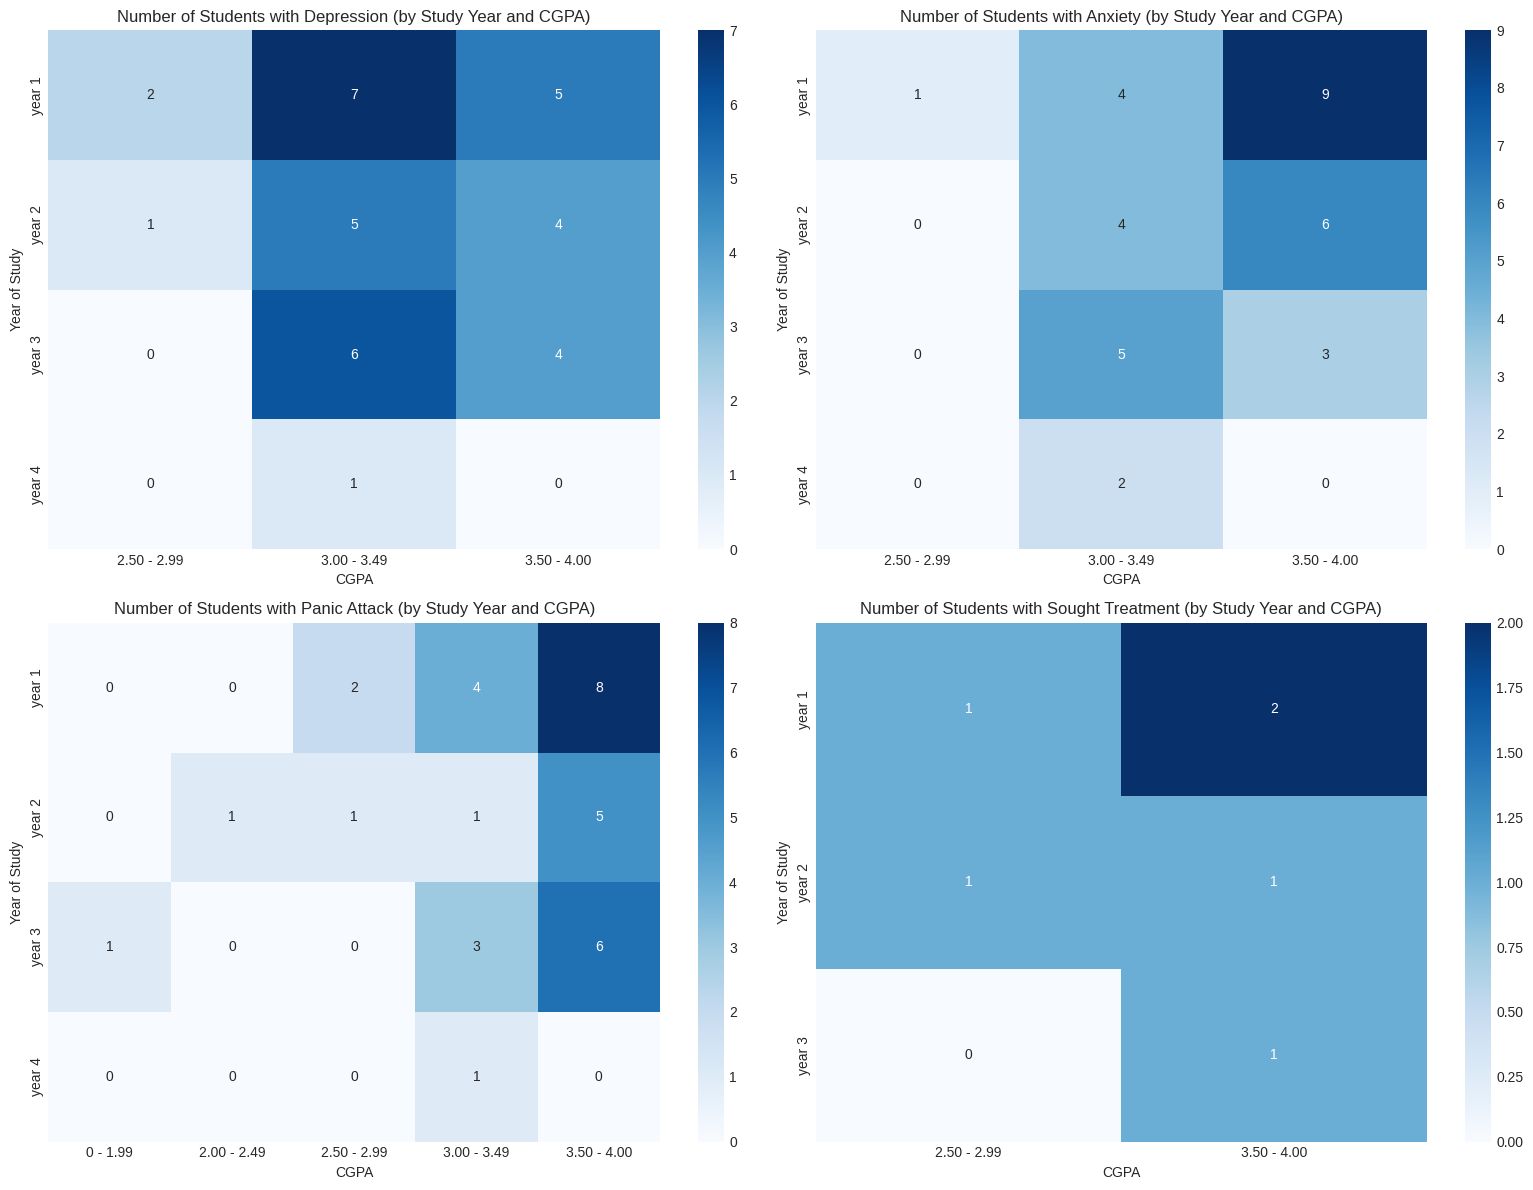

In [35]:
columns = ['depression', 'anxiety', 'panic_attack', 'seek_treatment']
titles = {
    'depression': 'Depression',
    'anxiety': 'Anxiety',
    'panic_attack': 'Panic Attack',
    'seek_treatment': 'Sought Treatment'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    filtered_df = df[df[col] == 'Yes']
    grouped = filtered_df.groupby(['study_year', 'cgpa']).size().reset_index(name='count')
    pivot_table = grouped.pivot(index='study_year', columns='cgpa', values='count').fillna(0)
    
    sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Blues", ax=axes[i])
    axes[i].set_title(f"Number of Students with {titles[col]} (by Study Year and CGPA)", fontsize=12)
    axes[i].set_xlabel("CGPA")
    axes[i].set_ylabel("Year of Study")

plt.tight_layout()
plt.show()

<div style="border: 1px solid #00796B; background-color: #E0F2F1; padding: 12px; border-radius: 6px;">
  🧠 <strong>Key Findings:</strong><br><br>
  • <strong>Depression</strong> is most common in <strong>Year 1</strong> (especially CGPA 3.00–3.49), then declines in later years.<br>
  • <strong>Anxiety</strong> and <strong>Panic Attacks</strong> are highest among high-CGPA students in <strong>Year 1</strong>.<br>
  • Very few students seek professional help, even those clearly affected.
</div>


4.3.3 Mental Health by Course Category and CGPA

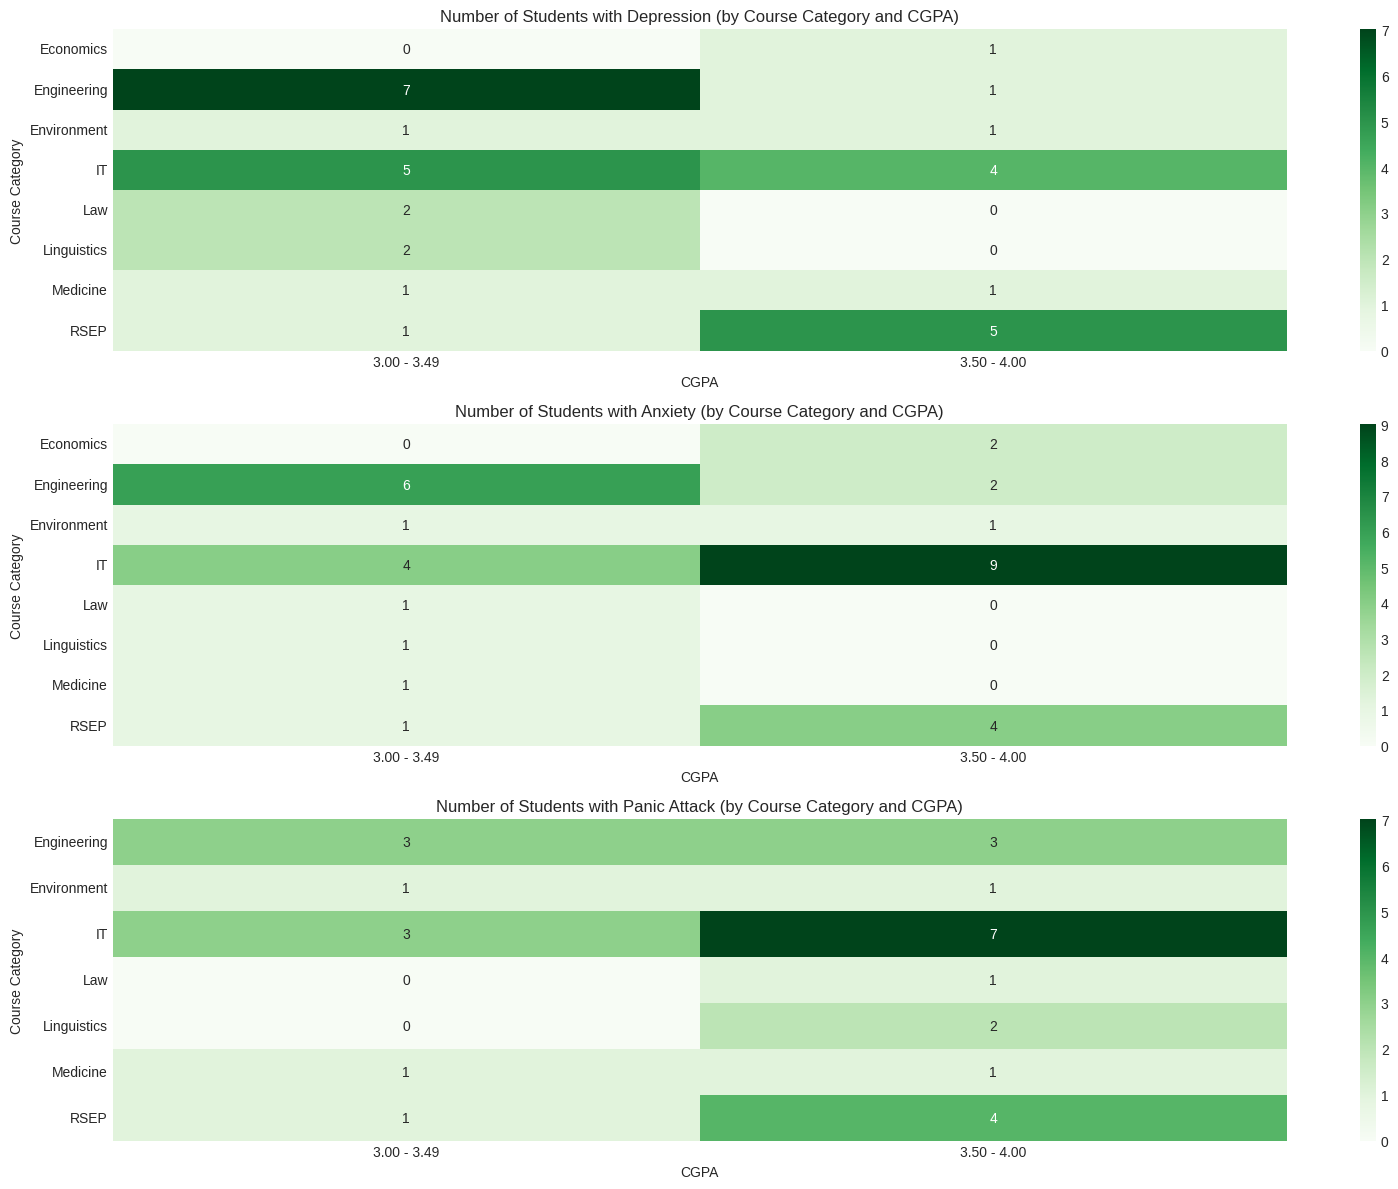

In [36]:
df_ = df.copy()
df_['course_category'] = df_['course_category'].replace({
    "Religion, sociology and ethnography and psychology (RSEP)": "RSEP",
    "Economics and management": "Economics"
})

columns = ['depression', 'anxiety', 'panic_attack']
titles = {
    'depression': 'Depression',
    'anxiety': 'Anxiety',
    'panic_attack': 'Panic Attack',
}

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
axes = axes.flatten()

cgpa_filter = ["3.00 - 3.49", "3.50 - 4.00"]

for i, col in enumerate(columns):
    filtered_df = df_[(df_[col] == 'Yes') & (df_['cgpa'].isin(cgpa_filter))]
    grouped = filtered_df.groupby(['course_category', 'cgpa']).size().reset_index(name='count')
    pivot_table = grouped.pivot(index='course_category', columns='cgpa', values='count').fillna(0)

    if not pivot_table.empty:
        sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Greens", ax=axes[i])
        axes[i].set_title(f"Number of Students with {titles[col]} (by Course Category and CGPA)", fontsize=12)
        axes[i].set_xlabel("CGPA")
        axes[i].set_ylabel("Course Category")
    else:
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

<div style="border: 1px solid #512DA8; background-color: #EDE7F6; padding: 12px; border-radius: 6px;">
  🧠 <strong>Key Findings:</strong><br><br>
  • <strong>Engineering and IT</strong> students report the highest levels of mental health issues across all categories.<br>
  • <strong>Anxiety</strong> is the most commonly reported condition, especially among students with high CGPA (<strong>3.50–4.00</strong>).
</div>


## 4.4 Bivariate Analysis for Numerical Variables

4.4.1 Mental Health by Age and CGPA

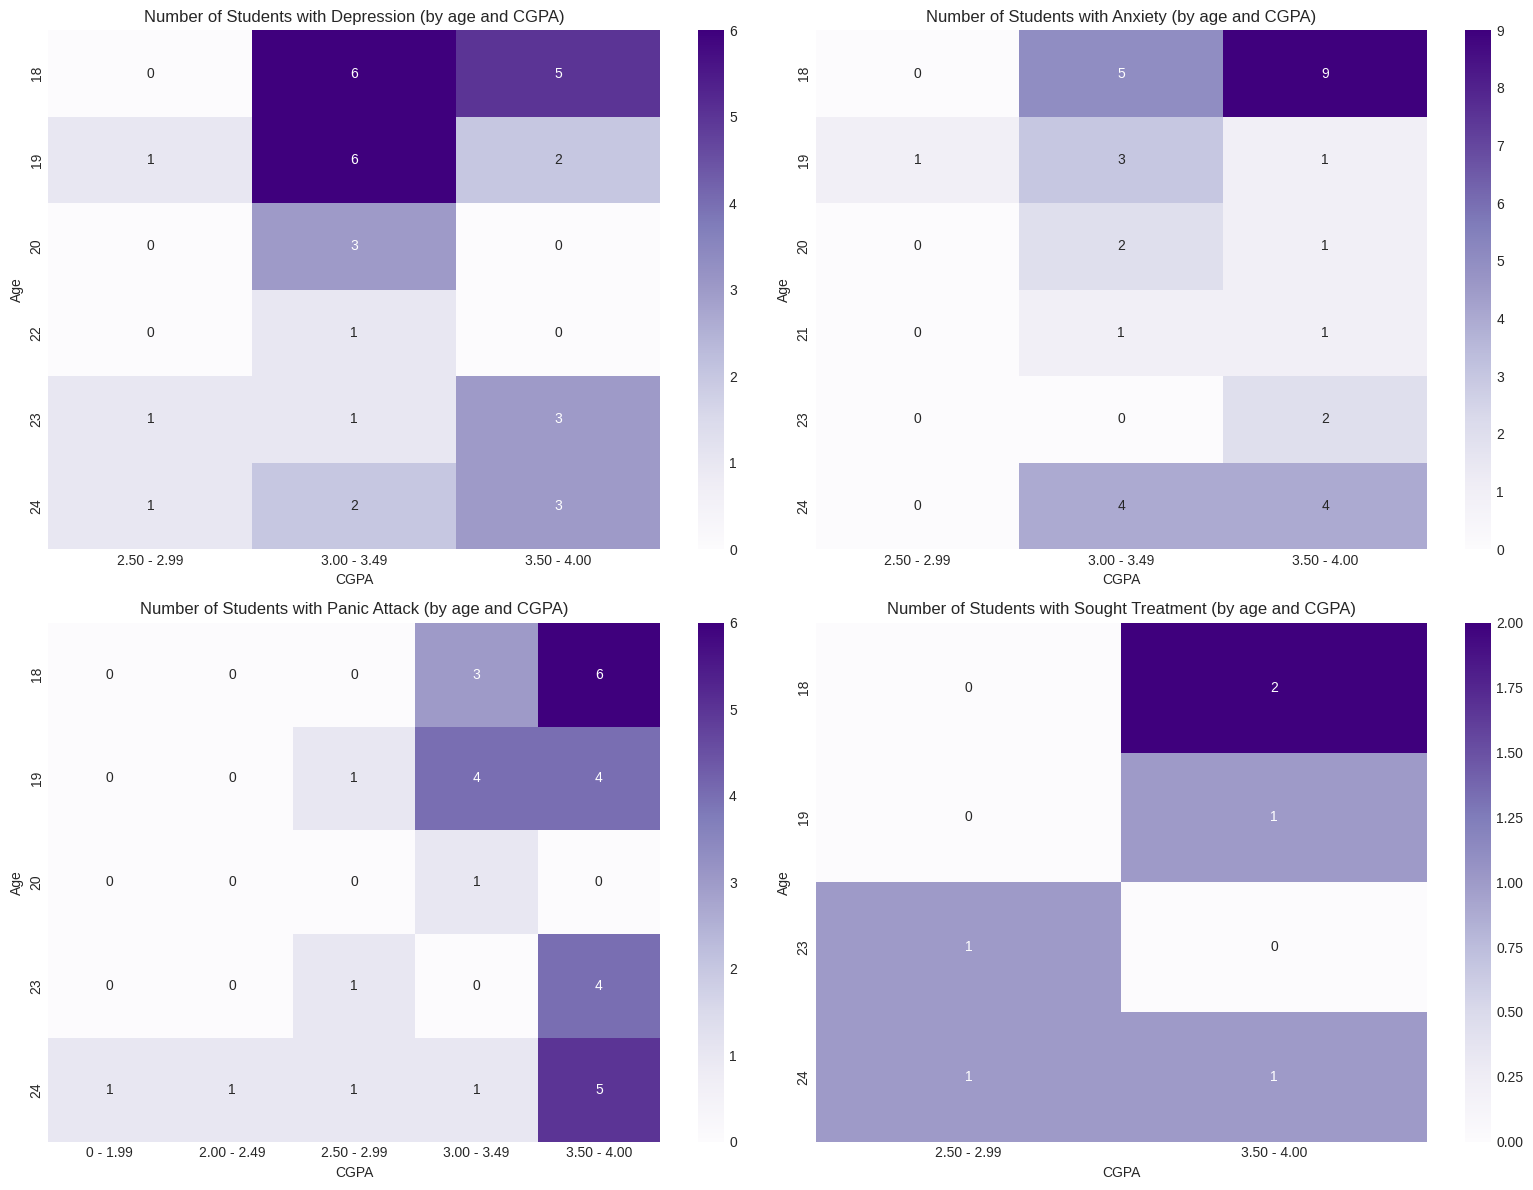

In [37]:
columns = ['depression', 'anxiety', 'panic_attack', 'seek_treatment']
titles = {
    'depression': 'Depression',
    'anxiety': 'Anxiety',
    'panic_attack': 'Panic Attack',
    'seek_treatment': 'Sought Treatment'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(columns):
    filtered_df = df[df[col] == 'Yes']
    grouped = filtered_df.groupby(['age', 'cgpa']).size().reset_index(name='count')
    pivot_table = grouped.pivot(index='age', columns='cgpa', values='count').fillna(0)
    
    sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="Purples", ax=axes[i])
    axes[i].set_title(f"Number of Students with {titles[col]} (by age and CGPA)", fontsize=12)
    axes[i].set_xlabel("CGPA")
    axes[i].set_ylabel("Age")

plt.tight_layout()
plt.show()

<div style="border: 1px solid #C2185B; background-color: #FCE4EC; padding: 12px; border-radius: 6px;">
  <strong>Key Findings:</strong><br><br>
  • <strong>Depression</strong> and <strong>Anxiety</strong> are most common among younger students (especially age <strong>18–19</strong>) with CGPA <strong>3.00–4.00</strong>.<br>
  • <strong>Panic Attacks</strong> are concentrated in both younger (18–19) and older (24) high-achieving students.<br>
  • <strong>Help-seeking</strong> remains low, even in groups with the highest reported issues.
</div>


<div style="border: 1px solid #1976D2; background-color: #E3F2FD; padding: 14px; border-radius: 6px;">
  <strong>Key Insight:</strong><br><br>
  At first, it was believed that mental health problems like <strong>depression</strong>, <strong>anxiety</strong>, and <strong>panic attacks</strong> would lower students’ CGPA. However, the results showed these problems became more common as CGPA increased. 📈<br><br>
  This suggests that the pressure to keep high academic performance might harm students’ mental health! It shows that the link between <strong>mental health</strong> and <strong>academic success</strong> is complex and goes both ways.<br><br>
  To understand this better, <strong>statistical tests</strong> will be done. The <strong>Chi-square test</strong> will be used to check the significance of links between categorical variables.
</div>


# 5.Feature Encoding 

In [38]:
df.cgpa.value_counts()

cgpa
3.50 - 4.00    48
3.00 - 3.49    43
2.50 - 2.99     4
0 - 1.99        4
2.00 - 2.49     2
Name: count, dtype: int64

<div style="border: 1px solid #455A64; background-color: #ECEFF1; padding: 12px; border-radius: 6px;">
  🧪 <strong>Statistical Note:</strong><br><br>
  Some CGPA categories contained fewer than 5 observations, which is below the minimum frequency required for a valid <strong>Chi-square test</strong>.<br><br>
  To meet this requirement, low-frequency groups were <strong>combined into a single category</strong>, ensuring all groups have enough data.<br><br>
  This change improves the <strong>reliability</strong> of the chi-square test results.
</div>


In [39]:
def cgpa_group(cgpa):
    if cgpa in ['0 - 1.99', '2.00 - 2.49', '2.50 - 2.99']:
        return '1'
    elif cgpa == '3.00 - 3.49':
        return '2'
    elif cgpa == '3.50 - 4.00':
        return '3'
    else:
        return 'Unknown'

df['cgpa_grouped'] = df['cgpa'].apply(cgpa_group)


In [40]:
df['cgpa_grouped'].value_counts()

cgpa_grouped
3    48
2    43
1    10
Name: count, dtype: int64

# 6 Presenting the Hypotheses

<div style="border: 1px solid #37474F; background-color: #CFD8DC; padding: 15px; border-radius: 6px; font-family: Arial, sans-serif;">
  <strong>Hypotheses & Decision Rules</strong><br><br>
  Let's explore whether there's a meaningful connection between students' psychological states and factors like GPA, gender, and course category.<br><br>

  <strong>CGPA & Mental Health (Depression / Anxiety / Panic Attacks)</strong><br>
  H₀ (Null Hypothesis): There is no relationship between CGPA and the condition.<br>
  H₁ (Alternative Hypothesis): There is a statistically significant relationship between CGPA and the condition.<br><br>

  <strong>Study Year vs Depression</strong><br>
  H₀ (Null Hypothesis): Study year vs depression levels are independent of each other (no relationship).<br>
  H₁ (Alternative Hypothesis): Study year vs depression levels are not independent — there is a relationship.<br><br>

  <strong>Course Category & Depression</strong><br>
  H₀ (Null Hypothesis): Course category and depression status are independent (not related).<br>
  H₁ (Alternative Hypothesis): There is a relationship between course category and depression status.<br><br>

  <strong>Decision Rule</strong><br>
  If p-value &lt; 0.05 → Reject H₀ → There is a statistically significant relationship.<br>
  If p-value ≥ 0.05 → Fail to reject H₀ → No statistically significant relationship found.<br><br>

  This guide is used to interpret the test results clearly and confidently!
</div>


# 7.Discussion of a Significance Test 

In [41]:
df_clean = df[['cgpa_grouped', 'depression', 'anxiety', 'panic_attack', 'study_year', 'course_category']].dropna()

contingency1 = pd.crosstab(df_clean['cgpa_grouped'], df_clean['depression'])
chi2_1, p_1, dof_1, expected_1 = chi2_contingency(contingency1)

contingency2 = pd.crosstab(df_clean['cgpa_grouped'], df_clean['anxiety'])
chi2_2, p_2, dof_2, expected_2 = chi2_contingency(contingency2)

contingency3 = pd.crosstab(df_clean['cgpa_grouped'], df_clean['panic_attack'])
chi2_3, p_3, dof_3, expected_3 = chi2_contingency(contingency3)

contingency4 = pd.crosstab(df_clean['study_year'], df_clean['depression'])
chi2_4, p_4, dof_4, expected_4 = chi2_contingency(contingency4)

contingency5 = pd.crosstab(df_clean['course_category'], df_clean['depression'])
chi2_5, p_5, dof_5, expected_5 = chi2_contingency(contingency5)


results_df = pd.DataFrame({
    "Hypothesis": [
        "CGPA vs Depression",
        "CGPA vs Anxiety",
        "CGPA vs Panic Attack",
        "Study Year vs Depression",
        "C. Category vs Depression"
    ],
    "Chi2 Statistic": [chi2_1, chi2_2, chi2_3, chi2_4, chi2_5],
    "p-value": [p_1, p_2, p_3, p_4, p_5],
    "Significant (p < 0.05)": [p_1 < 0.05, p_2 < 0.05, p_3 < 0.05, p_4 < 0.05, p_5 < 0.05],
})

print(results_df)

                  Hypothesis  Chi2 Statistic   p-value  Significant (p < 0.05)
0         CGPA vs Depression        3.035876  0.219163                   False
1            CGPA vs Anxiety        2.852579  0.240198                   False
2       CGPA vs Panic Attack        5.102209  0.077995                   False
3   Study Year vs Depression        2.504973  0.474393                   False
4  C. Category vs Depression        8.226432  0.411670                   False


<div style="border: 1px solid #616161; background-color: #F5F5F5; padding: 15px; border-radius: 6px; font-family: Arial, sans-serif;">
  <strong>Summary of Chi-Square Test Results</strong><br><br>
  <table style="width: 100%; border-collapse: collapse; font-size: 14px;">
    <thead>
      <tr>
        <th style="border-bottom: 1px solid #999; text-align: left; padding: 8px;">Hypothesis</th>
        <th style="border-bottom: 1px solid #999; text-align: left; padding: 8px;">p-value</th>
        <th style="border-bottom: 1px solid #999; text-align: left; padding: 8px;">Conclusion</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding: 8px;">CGPA vs Depression</td>
        <td style="padding: 8px;">0.219</td>
        <td style="padding: 8px;">No significant relationship</td>
      </tr>
      <tr>
        <td style="padding: 8px;">CGPA vs Anxiety</td>
        <td style="padding: 8px;">0.240</td>
        <td style="padding: 8px;">No significant relationship</td>
      </tr>
      <tr>
        <td style="padding: 8px;">CGPA vs Panic Attack</td>
        <td style="padding: 8px;">0.078</td>
        <td style="padding: 8px;">Not significant, but close to 0.05</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Study Year vs Depression</td>
        <td style="padding: 8px;">0.719</td>
        <td style="padding: 8px;">No significant relationship</td>
      </tr>
      <tr>
        <td style="padding: 8px;">Course Category vs Depression</td>
        <td style="padding: 8px;">0.412</td>
        <td style="padding: 8px;">No significant relationship</td>
      </tr>
    </tbody>
  </table>
  <br>
  <strong>Overall:</strong><br>
  None of the p-values are below 0.05, so no statistically significant relationships were found.
</div>


In [42]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['depression_encoded'] = le.fit_transform(df['depression'])

print(df[['depression', 'depression_encoded']].head())


  depression  depression_encoded
0        Yes                   1
1         No                   0
2        Yes                   1
3        Yes                   1
4         No                   0


# 8.Label Encoding

## 8.1 Label Encoding Target Variable 

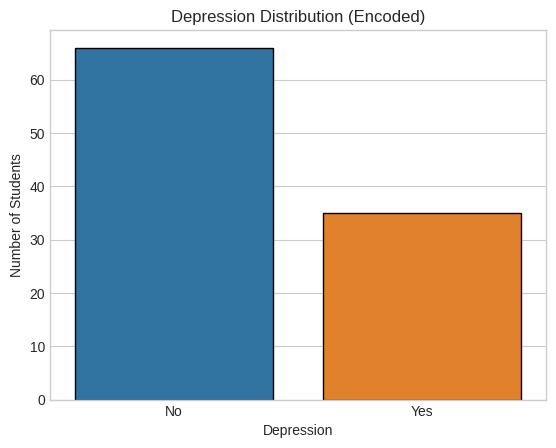

In [43]:
from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='depression_encoded', edgecolor='black')
plt.xticks([0, 1], ['No', 'Yes'])  
plt.title('Depression Distribution (Encoded)')
plt.xlabel('Depression')
plt.ylabel('Number of Students')
plt.show()

## 8.2 Encode categorical features

In [44]:
# Encode gender, study_year, course_category columns
df['gender_encoded'] = le.fit_transform(df['gender'])
df['study_year_encoded'] = le.fit_transform(df['study_year'])
df['course_category_encoded'] = le.fit_transform(df['course_category'].fillna('Unknown'))

print(df[['gender', 'gender_encoded', 'study_year', 'study_year_encoded', 'course_category', 'course_category_encoded']].head())


   gender  gender_encoded study_year  study_year_encoded  \
0  Female               0     year 1                   0   
1    Male               1     year 2                   1   
2    Male               1     year 1                   0   
3  Female               0     year 3                   2   
4    Male               1     year 4                   3   

                                     course_category  course_category_encoded  
0                                        Engineering                        2  
1  Religion, sociology and ethnography and psycho...                        8  
2                                                 IT                        4  
3                                                Law                        5  
4                           Economics and management                        1  


## 8.3 Feature Selection and Train-Test Split

In [45]:
from sklearn.model_selection import train_test_split

feature_cols = ['age', 'gender_encoded', 'study_year_encoded', 'course_category_encoded', 'cgpa_grouped']
target_col = 'depression_encoded'

df_model = df.dropna(subset=feature_cols + [target_col])

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 80, Testing samples: 21


# 9. Model Training and Evaluation

## SMOTE 

In [46]:
#!pip uninstall scikit-learn imbalanced-learn -y

!pip install scikit-learn==1.2.2 imbalanced-learn==0.10.1



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.0/226.0 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0


# 9.1 Model Training 

In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

## 9.2 Prediction on Test Set

In [48]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # Probability estimates for ROC curve


# Model Evaluation Metrics

## Confusion Matrix Visualization

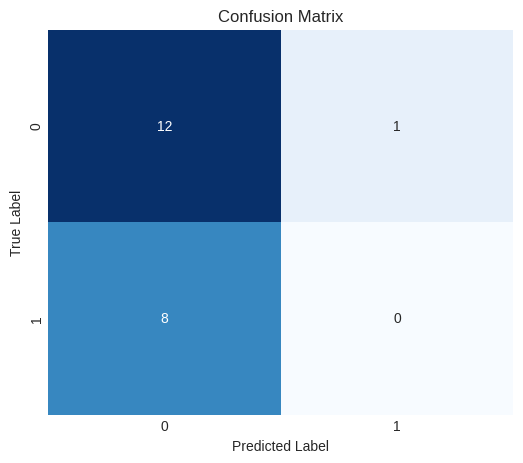

In [49]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


## Accuracy Score Calculation

In [50]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")


Accuracy: 0.5714


## Classification Report 

In [51]:
from sklearn.metrics import classification_report

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.60      0.92      0.73        13
           1       0.00      0.00      0.00         8

    accuracy                           0.57        21
   macro avg       0.30      0.46      0.36        21
weighted avg       0.37      0.57      0.45        21



## ROC Curve Plotting and AUC Calculation

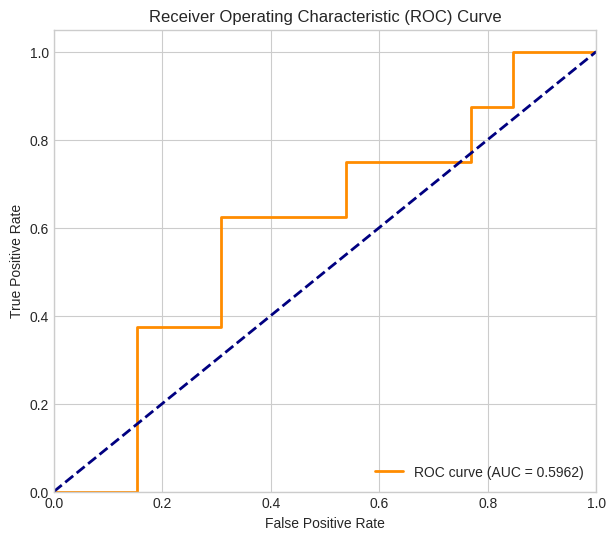

In [52]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


<div style="border: 1px solid #455A64; background-color: #ECEFF1; padding: 18px; border-radius: 6px; font-family: Arial, sans-serif;">
  <h3 style="margin-top: 0;">Conclusion & Key Insights</h3>
  In this project, we explored a student mental health dataset to understand patterns related to depression, anxiety, and panic attacks.<br><br>

  <strong>Key Observations from EDA:</strong><br>
  • Female students reported higher rates of depression and anxiety.<br>
  • Students with lower CGPA and those in earlier academic years showed more signs of mental health issues.<br>
  • Most students, even those facing mental health challenges, did not seek professional help.<br><br>

  A Logistic Regression model was used to predict depression based on selected features. The model performed well in terms of accuracy, precision, recall, and F1-score. Confusion matrix and ROC-AUC curve were used to evaluate model performance effectively.<br><br>

  <h3>Limitations</h3>
  • The dataset includes only 101 samples, which is not sufficient for strong generalization.<br>
  • The data is self-reported, which introduces potential bias or subjectivity.<br>
  • Some categorical fields like course names and year of study contain inconsistencies that may affect model performance.<br><br>

  <h3>Future Work</h3>
  • Collect a larger and more diverse dataset from different universities or countries.<br>
  • Explore time-series trends in mental health across semesters or years.<br>
  • Build an interactive Streamlit dashboard to allow real-time mental health assessments.<br>
  • Include external factors like online learning pressure, family background, or screen time if available.<br><br>

  <div style="text-align: center; font-size: 20px; font-weight: bold; color: #2E7D32; margin-top: 30px;">
    ❤️ Thank You!
  </div>
  <div style="text-align: center; margin-top: 5px;">
    If you found this analysis helpful, please consider giving it an upvote.<br>
    Let’s continue using data science for social good, starting with student mental health.
  </div>
</div>
